# GESO example: HalfMBB Beam

## Commented Program

What follows is a program spliced with comments.

In [1]:
using TopOpt

Precompiling packages...
   2623.8 ms  ✓ DataStructures
    945.0 ms  ✓ SortingAlgorithms
   3972.6 ms  ✓ StarAlgebras
   4072.7 ms  ✓ QuadGK
   5188.5 ms  ✓ MultivariatePolynomials
   8970.5 ms  ✓ VTKDataTypes
   5815.4 ms  ✓ StatsBase
   1217.0 ms  ✓ PDMats → StatsBaseExt
   3449.6 ms  ✓ MultivariatePolynomials → MultivariatePolynomialsChainRulesCoreExt
  12504.4 ms  ✓ Ferrite
   4840.3 ms  ✓ DynamicPolynomials
   6171.1 ms  ✓ Optim
   6703.5 ms  ✓ Distributions
   3098.5 ms  ✓ Optim → OptimMOIExt
   1870.6 ms  ✓ Distributions → DistributionsTestExt
   2700.5 ms  ✓ Distributions → DistributionsChainRulesCoreExt
   5697.1 ms  ✓ NonconvexMMA
  32735.8 ms  ✓ SymbolicUtils
   2724.1 ms  ✓ SymbolicLimits
   4903.2 ms  ✓ SymbolicUtils → SymbolicUtilsReverseDiffExt
  33529.6 ms  ✓ Symbolics
   2591.1 ms  ✓ DifferentiationInterface → DifferentiationInterfaceSymbolicsExt
   3702.5 ms  ✓ Symbolics → SymbolicsForwardDiffExt
   5368.5 ms  ✓ NonconvexUtils
   4157.4 ms  ✓ Nonconvex
Info Given Top

### Define the problem

In [2]:
E = 1.0 # Young’s modulus
v = 0.3 # Poisson’s ratio
f = 1.0; # downward force

nels = (160, 40)
problem = HalfMBB(Val{:Linear}, nels, (1.0, 1.0), E, v, f)

TopOpt half MBB problem


### Define the FEA Solver and penalty functions

In [3]:
solver = FEASolver(DirectSolver, problem; xmin=0.01, penalty=TopOpt.PowerPenalty(3.0))

TopOpt direct structural solver (GenericFEASolver)


### Define the compliance objective function and volume fraction constraint

In [4]:
comp = Compliance(solver)
volfrac = Volume(solver)
sensfilter = SensFilter(solver; rmin=4.0)
geso = GESO(comp, volfrac, 0.5, sensfilter)

TopOpt GESO algorithm


### Run optimization

In [5]:
x0 = ones(length(solver.vars))
result = geso(x0)

TopOpt.Algorithms.GESOResult{Float64, Vector{Float64}}([1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0  …  0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 520.3307225333364, 0.0006149449130166403, true, 45)

### (Optional) Visualize the result using Makie.jl
Need to run `using Pkg; Pkg.add("Makie")` first and either `Pkg.add("CairoMakie")` or `Pkg.add("GLMakie")`

In [6]:
using Makie
using CairoMakie

Precompiling packages...
   1497.6 ms  ✓ KernelDensity
   8462.8 ms  ✓ MathTeXEngine
  33374.1 ms  ✓ TiffImages
 141860.4 ms  ✓ Makie
  4 dependencies successfully precompiled in 175 seconds. 269 already precompiled.
Precompiling packages...
   4318.6 ms  ✓ DomainSets → DomainSetsMakieExt
  1 dependency successfully precompiled in 5 seconds. 277 already precompiled.
Precompiling packages...
   4819.8 ms  ✓ SciMLBase → SciMLBaseMakieExt
  1 dependency successfully precompiled in 5 seconds. 303 already precompiled.
Precompiling packages...
  11502.6 ms  ✓ TopOpt → TopOptMakieExt
  1 dependency successfully precompiled in 13 seconds. 455 already precompiled.
Precompiling packages...
  41200.7 ms  ✓ CairoMakie
  1 dependency successfully precompiled in 41 seconds. 278 already precompiled.


alternatively, `using GLMakie`

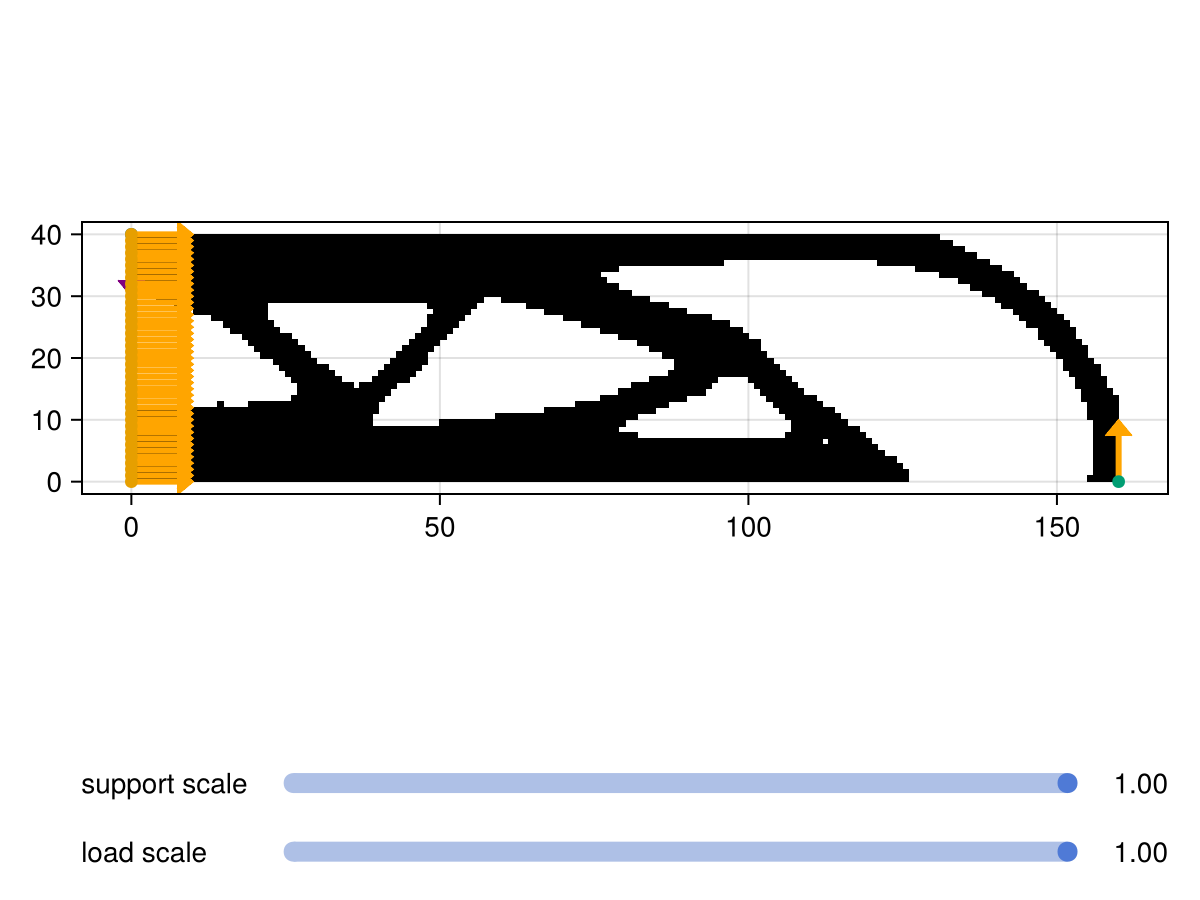

CairoMakie.Screen{IMAGE}


In [7]:
fig = visualize(problem; topology=result.topology)
Makie.display(fig)

---

*This notebook was generated using [Literate.jl](https://github.com/fredrikekre/Literate.jl).*